# Imports

In [1]:
## Import Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
from torch.utils.tensorboard import SummaryWriter 
import json
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from sklearn.manifold import spectral_embedding
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import rbf_kernel

## Import Dataset Classes
from dataset_classes import ISO_NE, AT, SH_Dataset

## Import Model
from models_with_temporal_graph import TR_GNN_MultiScale

## Import Training and Testing Loops
from helper_functions import train_model, test_model, test_model_stepwise

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Stepwise Error

Loaded dataset with 27 features (target=load), total rows=17258
Raw data length: 17258
Scaler 'train_size' (raw rows): 10354
Scaler 'val_end' (raw rows): 13806

🔍 Generating Feature Clusters...
Total valid samples: 16946
Train samples: 10042, Val samples: 3212, Test samples: 3212

🚚 DataLoaders ready. Train batches: 314, Val batches: 101, Test batches: 101

Loading checkpoint:
Sensitivity_Analysis_SH/best_models/dilation_5_best_model.pth
✅ Best SH model loaded successfully


Testing: 100%|██████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 177.74it/s]



--- Overall Test Results (3,212 points) ---
[Scaled]   Overall MSE = 0.2031 | Overall MAE = 0.3415
[Unscaled] Overall MSE = 3492559.7393 | Overall MAE = 1416.1608 (MW)

--- Error Decomposition at Specific Steps ---
Step  60:
  Scaled   -> MSE = 0.1465 | MAE = 0.2882
  Unscaled -> MSE = 2518696.9407 | MAE = 1195.2322
Step 120:
  Scaled   -> MSE = 0.2073 | MAE = 0.3523
  Unscaled -> MSE = 3564508.2864 | MAE = 1461.1993
Step 180:
  Scaled   -> MSE = 0.2705 | MAE = 0.4123
  Unscaled -> MSE = 4652484.6870 | MAE = 1709.9932
Step 240:
  Scaled   -> MSE = 0.2929 | MAE = 0.4186
  Unscaled -> MSE = 5037300.1166 | MAE = 1735.9415


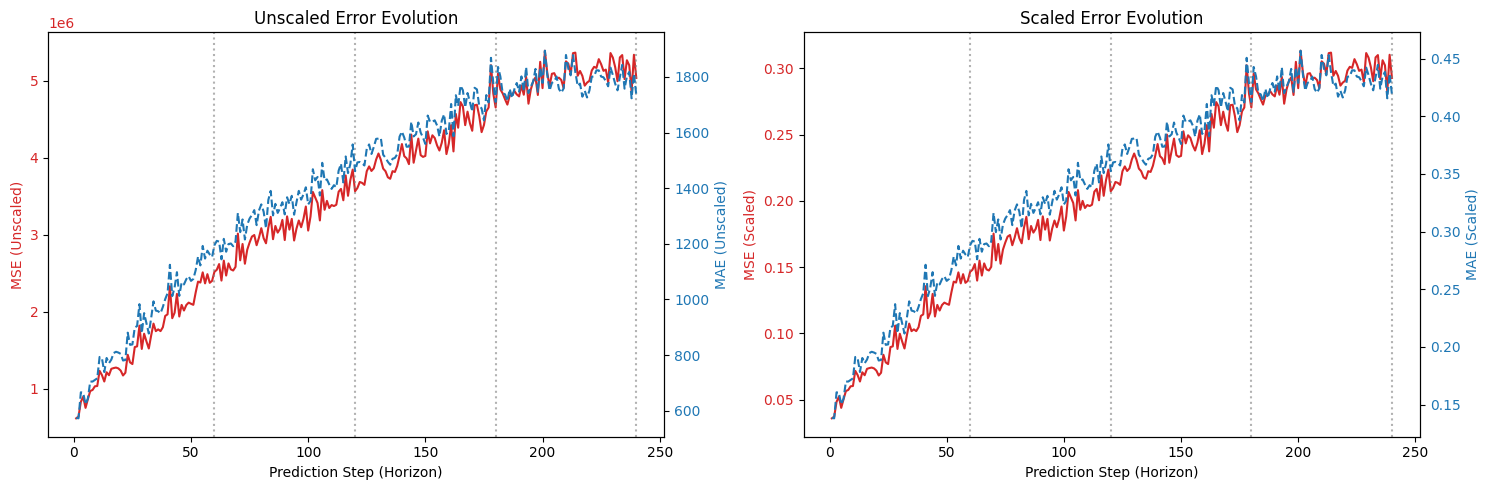


Plots saved to SH_Stepwise_Predictions/dilation_5.jpg


In [23]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = SH_Dataset(
        csv_path="sh_dataset.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    
    print("\n🔍 Generating Feature Clusters...")
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  
    
    train_end = train_split_idx - dataset.T_in - dataset.T_out
    val_start = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in - dataset.T_out
    test_start = val_split_idx - dataset.T_in
    
    effective_len = len(dataset)
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(val_start, val_end)
    test_idx = range(test_start, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    # DataLoaders can be reused since batch_size doesn't change in this sensitivity analysis
    train_loader = DataLoader(train_subset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

    ##
    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-3,
        "scheduler_patience": 3,
        "batch_size": 32,
        "epochs": 100,
        "weight_decay": 1e-4,
        "kernel_size": 7,
        "dilation": 5,
    }
    ##
    
    # --- Model ---
    model = TR_GNN_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
        kernel_size=hparams["kernel_size"],
        dilation=hparams["dilation"],
    ).to(device)

    ##
    checkpoint_path = (
        "Sensitivity_Analysis_SH/"
        "best_models/"
        "dilation_5_best_model.pth"
    )
    ##

    print(f"\nLoading checkpoint:\n{checkpoint_path}")

    ckpt = torch.load(
        checkpoint_path,
        map_location=device
    )

    if "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)

    model.eval()

    print("✅ Best SH model loaded successfully")
    os.makedirs("SH_Stepwise_Predictions", exist_ok=True)
    test_model_stepwise(
        dataset = dataset,
        model = model,
        test_loader = test_loader,
        device = device,
        save_plot_path = "SH_Stepwise_Predictions/dilation_5.jpg" ##
    )
if __name__ == "__main__":
    main()